In [86]:
# from astroquery.utils.tap.core import TapPlus
import pandas as pd
import numpy as np
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [115]:
# Fetch data
query = """
SELECT TOP 10000
    gs.source_id,
    gs.ra,
    gs.dec,
    gs.parallax,
    gs.phot_g_mean_mag,
    gs.bp_rp,
    gs.teff_gspphot,
    gs.logg_gspphot,
    gs.mh_gspphot,
    gs.pm,
    gs.radial_velocity,
    ap.lum_flame,
    ap.radius_flame,
    ap.mass_flame
FROM gaiadr3.gaia_source AS gs
JOIN gaiadr3.astrophysical_parameters AS ap
ON gs.source_id = ap.source_id
WHERE parallax_over_error > 20
"""

job = Gaia.launch_job_async(query)
stars = job.get_results()
df = stars.to_pandas()

INFO: Query finished. [astroquery.utils.tap.core]


In [101]:
df.shape

(1212, 14)

In [116]:
df["mag"] = df["phot_g_mean_mag"] + 5 + 5 * np.log10(df["parallax"] / 1000)
df.to_csv("Sample_data_both_table.csv")

In [108]:

params = ["bp_rp", "parallax", "logg_gspphot", "mh_gspphot", "pm", "radial_velocity", "lum_flame", "radius_flame", "mass_flame"]

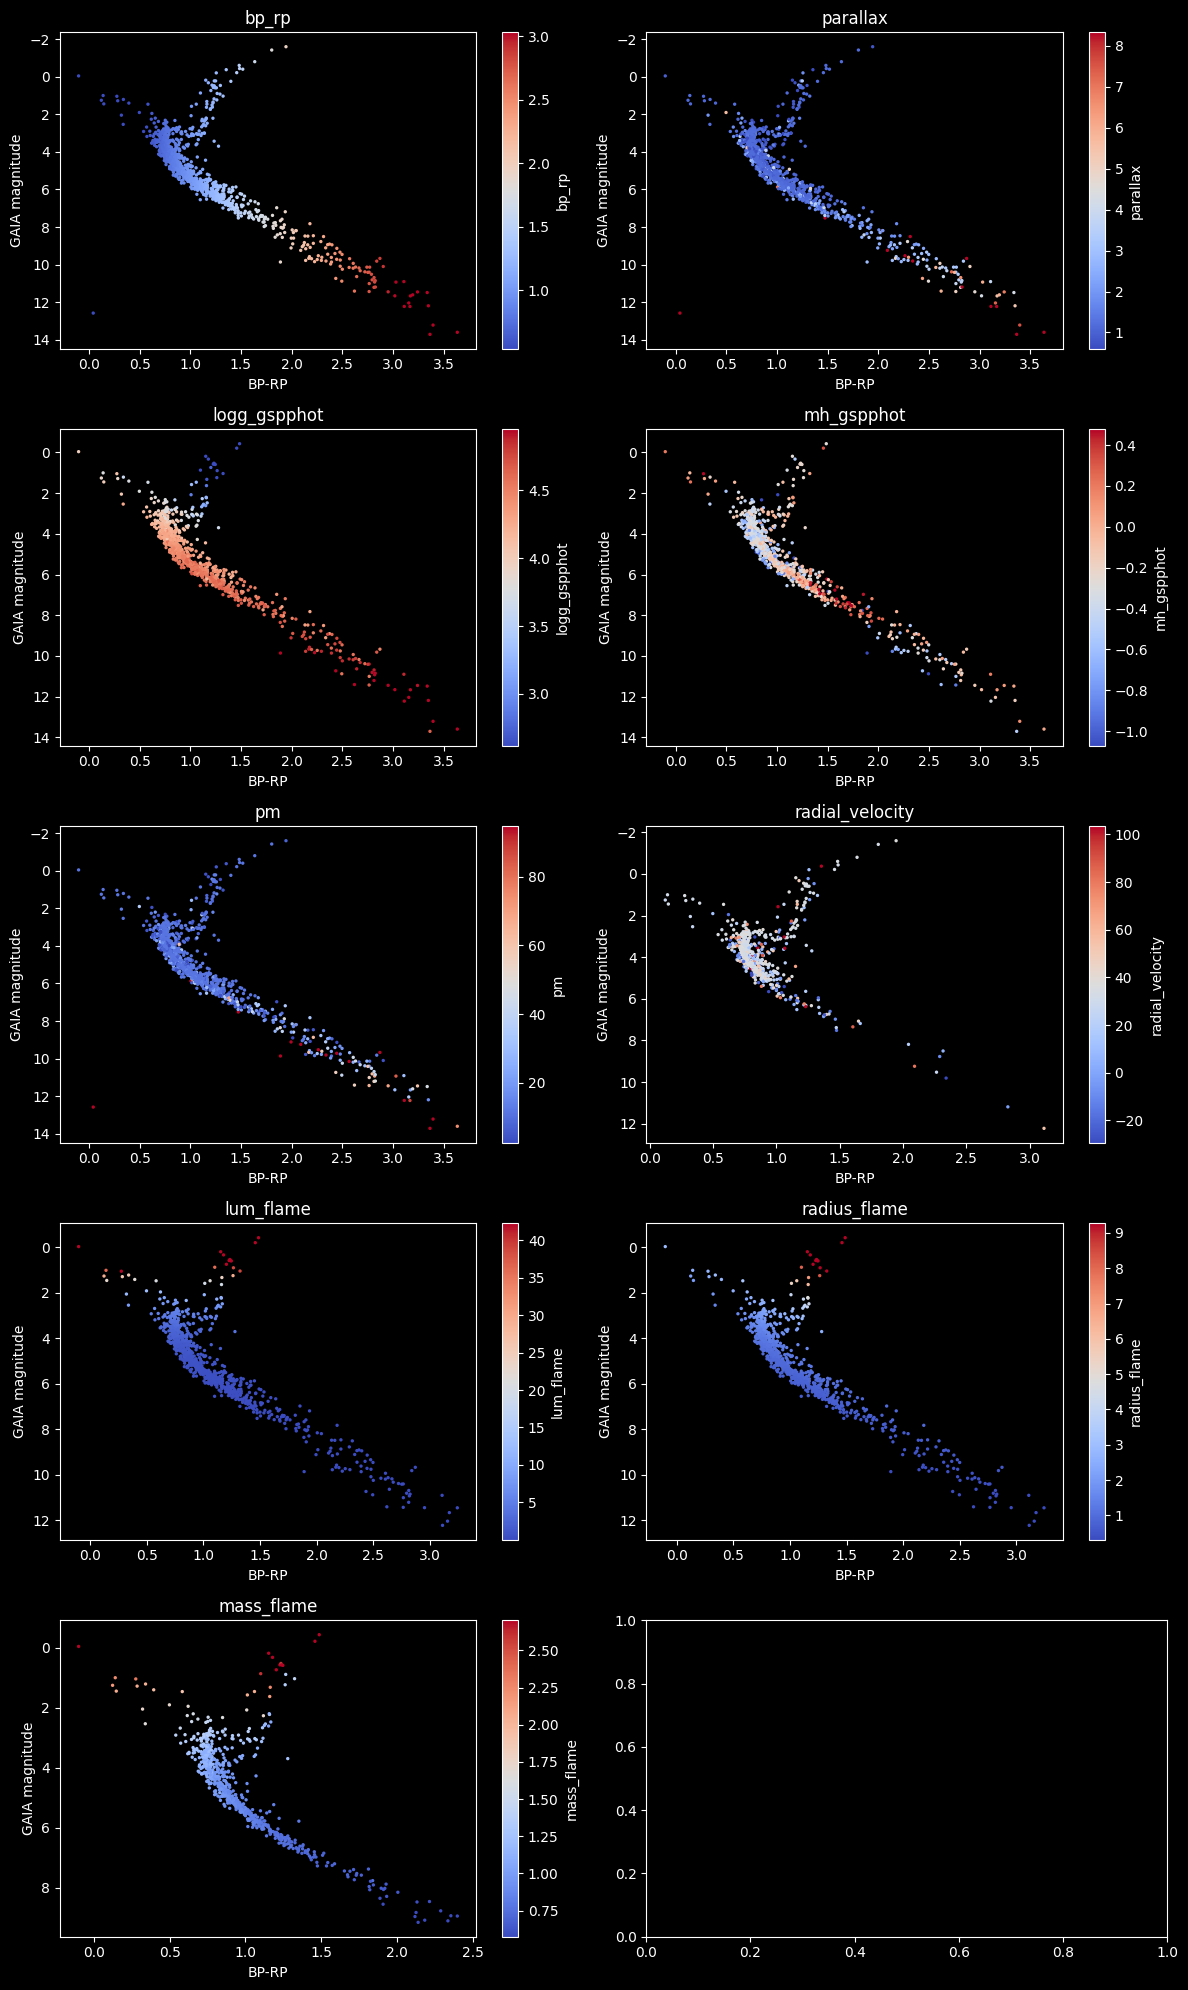

In [111]:
plt.style.use(["dark_background"])
fig, axs = plt.subplots(5, 2, figsize=(12, 20))

for ax, param in zip(axs.flat, params):
    ax.yaxis.set_inverted(True)
    sc = ax.scatter(df["bp_rp"], df["mag"], s=2, cmap="coolwarm", c=df[param], vmax=np.nanpercentile(df[param], 99), vmin=np.nanpercentile(df[param], 1))
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("GAIA magnitude")
    ax.set_title(param)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(param)
plt.tight_layout()
plt.show()